In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv
/kaggle/input/tabular-playground-series-nov-2021/train.csv
/kaggle/input/tabular-playground-series-nov-2021/test.csv


In [2]:
# import sys
# !cp ../input/rapids/rapids.21.06 /opt/conda/envs/rapids.tar.gz
# !cd /opt/conda/envs/ && tar -xzvf rapids.tar.gz > /dev/null
# sys.path = ["/opt/conda/envs/rapids/lib/python3.7/site-packages"] + sys.path
# sys.path = ["/opt/conda/envs/rapids/lib/python3.7"] + sys.path
# sys.path = ["/opt/conda/envs/rapids/lib"] + sys.path 
# !cp /opt/conda/envs/rapids/lib/libxgboost.so /opt/conda/lib/

In [3]:
# import cuml

In [4]:
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from cuml.manifold import TSNE
import seaborn as sns
from  sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier

In [5]:
train = pd.read_csv('../input/tabular-playground-series-nov-2021/train.csv', skiprows=lambda x:x%5!=0)


In [6]:
test = pd.read_csv('../input/tabular-playground-series-nov-2021/test.csv')

In [7]:
memory_train = sum(train.memory_usage()) / 1e6
print(f'[INFO] Memory usage train_before: {memory_train:.2f} MB.')

memory_test = sum(test.memory_usage()) / 1e6
print(f'[INFO] Memory usage test_before: {memory_test:.2f} MB.\n')

# Downcasting the traind dataset.
for col in train.columns:
    
    if train[col].dtype == "float64":
        train[col] = pd.to_numeric(train[col], downcast="float")
        
    if train[col].dtype == "int64":
        train[col] = pd.to_numeric(train[col], downcast="integer")
        
# Downcasting the test dataset.
for col in test.columns:
    
    if test[col].dtype == "float64":
        test[col] = pd.to_numeric(test[col], downcast="float")
        
    if test[col].dtype == "int64":
        test[col] = pd.to_numeric(test[col], downcast="integer")
        
memory_train = sum(train.memory_usage()) / 1e6
print(f'[INFO] Memory usage train: {memory_train:.2f} MB.')

memory_test = sum(test.memory_usage()) / 1e6
print(f'[INFO] Memory usage test: {memory_test:.2f} MB.')

[INFO] Memory usage train_before: 97.92 MB.
[INFO] Memory usage test_before: 436.32 MB.

[INFO] Memory usage train: 48.60 MB.
[INFO] Memory usage test: 218.16 MB.


In [8]:
sub = pd.read_csv('../input/tabular-playground-series-nov-2021/sample_submission.csv')

In [9]:
train.shape

(120000, 102)

In [10]:
train.isna().sum().unique()

array([0])

In [11]:
train.target.unique()

array([1, 0], dtype=int8)

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


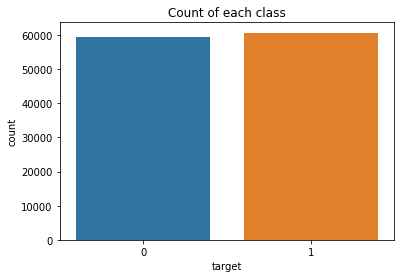

In [12]:
import seaborn as sns
sns.countplot(train['target'])
plt.title('Count of each class')
plt.show()

In [13]:
X=train.drop(['id','target'], axis=1)
y=train['target']
train.iloc[:,1:].shape

(120000, 101)

In [14]:
train.iloc[:,1:-1].columns

Index(['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10',
       'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20',
       'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30',
       'f31', 'f32', 'f33', 'f34', 'f35', 'f36', 'f37', 'f38', 'f39', 'f40',
       'f41', 'f42', 'f43', 'f44', 'f45', 'f46', 'f47', 'f48', 'f49', 'f50',
       'f51', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57', 'f58', 'f59', 'f60',
       'f61', 'f62', 'f63', 'f64', 'f65', 'f66', 'f67', 'f68', 'f69', 'f70',
       'f71', 'f72', 'f73', 'f74', 'f75', 'f76', 'f77', 'f78', 'f79', 'f80',
       'f81', 'f82', 'f83', 'f84', 'f85', 'f86', 'f87', 'f88', 'f89', 'f90',
       'f91', 'f92', 'f93', 'f94', 'f95', 'f96', 'f97', 'f98', 'f99'],
      dtype='object')

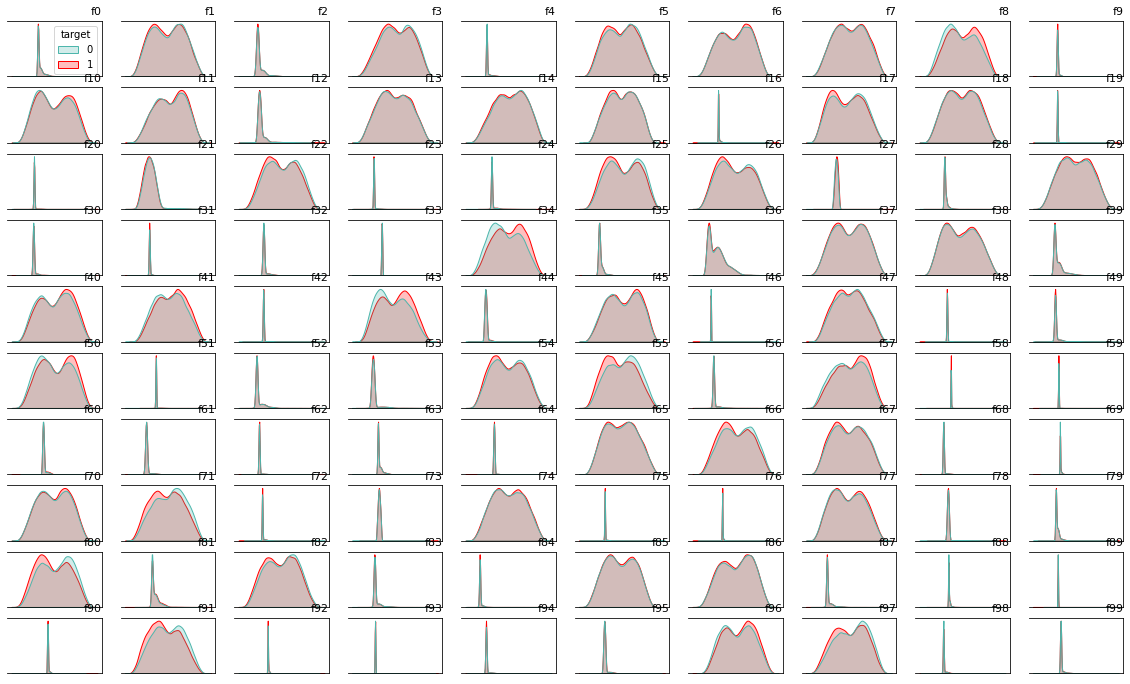

In [15]:
fig, axes = plt.subplots(10,10, figsize=(20, 12))
type(axes)
axes = axes.flatten()
type(axes)
for idx, ax in enumerate(axes):
    sns.kdeplot(data=train.iloc[:,1:],hue='target' ,ax=ax, fill=True,
        x=f'f{idx}', palette=['#4DB6AC', 'red'], legend=idx==0
    )
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel('')
    ax.set_ylabel(''); ax.spines['left'].set_visible(False)
    ax.set_title(f'f{idx}', loc='right' , fontsize=11)
plt.show()
    

In [16]:
candles_features = [
    'f0','f2','f4','f9','f12','f16','f19','f20','f23','f24','f27',
    'f28','f30','f31','f32','f33','f35','f39','f42','f44','f46','f48',
    'f49','f51','f52','f53','f56','f58','f59','f60','f61','f62','f63',
    'f64','f68','f69','f72','f73','f75','f76','f78','f79','f81','f83',
    'f84','f87','f88','f89','f90','f92','f93','f94','f95','f98','f99'
]

<AxesSubplot:ylabel='Density'>

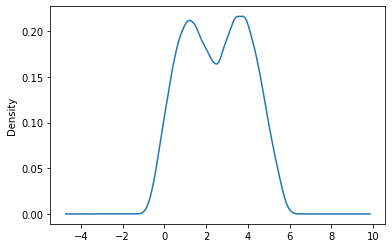

In [17]:
train['f1'].plot.kde()

<AxesSubplot:ylabel='Density'>

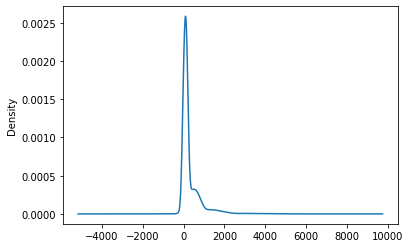

In [18]:
train['f2'].plot.kde()

<AxesSubplot:>

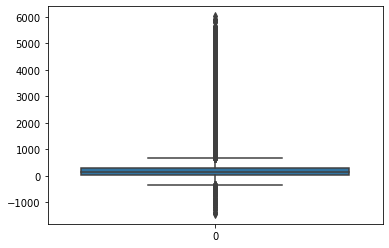

In [19]:
sns.boxplot(data=train['f2'])

In [20]:
# train.describe().T.sort_values('std' , ascending=False)

In [21]:
train[candles_features].describe().T

,count,mean,std,min,25%,50%,75%,max
f0,120000.0,0.307052,0.523047,-3.388780,0.026016,0.097800,0.398088,8.012060
f2,120000.0,305.293121,550.226013,-1440.880005,42.893676,132.999001,300.802002,6019.500000
f4,120000.0,0.177230,0.416000,-2.534540,0.019683,0.061472,0.112840,8.265470
f9,120000.0,0.136230,0.423220,-2.577840,0.019528,0.058917,0.101507,6.907020
f12,120000.0,0.129500,0.211884,-0.626604,0.029231,0.072916,0.127690,2.361230
f16,120000.0,0.363063,1.353923,-17.400600,-0.045786,0.071833,0.210794,41.469200
f19,120000.0,0.107984,0.395594,-4.416530,0.017403,0.059557,0.102501,11.619100
f20,120000.0,0.093163,0.308508,-2.858550,0.018889,0.056273,0.094526,8.401730
f23,120000.0,0.097371,0.333592,-2.678530,0.011659,0.049814,0.090505,8.382750
f24,120000.0,0.141631,0.342359,-2.541760,0.017824,0.056827,0.101505,6.101230


In [22]:

df_candles_log_transform = train[candles_features]

mask_neg = (df_candles_log_transform < 0)
mask_pos = (df_candles_log_transform > 0)

df_candles_log_transform[mask_neg] = np.log(np.abs(df_candles_log_transform)) * (-1)
df_candles_log_transform[mask_pos] = np.log(df_candles_log_transform)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:3718: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._where(-key, value, inplace=True)
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

In [23]:
df_candles_log_transform.describe().T

,count,mean,std,min,25%,50%,75%,max
f0,120000.0,-0.990802,2.539528,-11.907995,-2.650131,-1.541950,0.031964,13.374608
f2,120000.0,3.846035,3.335495,-7.273009,3.759679,4.890405,5.706475,8.702760
f4,120000.0,-1.543452,2.742906,-12.654857,-3.093223,-2.416761,-0.674584,12.654929
f9,120000.0,-1.709731,2.730186,-12.415183,-3.134622,-2.494468,-1.840793,13.736746
f12,120000.0,-1.764223,2.453692,-13.294689,-3.002997,-2.363493,-1.417102,13.282497
f16,120000.0,-0.227128,2.535507,-11.513921,-2.138657,-1.092367,1.984664,14.226701
f19,120000.0,-1.637071,2.757503,-13.751991,-3.072959,-2.439428,-1.906383,13.483104
f20,120000.0,-1.801344,2.737165,-14.846164,-3.172935,-2.549429,-2.051521,13.257210
f23,120000.0,-1.599113,2.950997,-13.979840,-3.215978,-2.545716,-1.825168,12.639120
f24,120000.0,-1.631736,2.790153,-13.367855,-3.165403,-2.498104,-0.972700,13.740013


In [24]:
train[candles_features]=df_candles_log_transform[candles_features]

In [25]:
 train.describe().T.sort_values('std' , ascending=False)

,count,mean,std,min,25%,50%,75%,max
id,120000.0,300001.500000,173205.802443,4.000000,150002.750000,300001.500000,450000.250000,599999.000000
f2,120000.0,3.846035,3.335495,-7.273009,3.759679,4.890405,5.706475,8.702760
f31,120000.0,-1.344802,3.090129,-12.544220,-3.188219,-2.474203,-0.320848,13.877153
f48,120000.0,-1.678813,2.993584,-15.947577,-3.287416,-2.626933,-2.003512,16.668627
f75,120000.0,-1.125151,2.975814,-15.064390,-2.984541,-2.265116,0.711425,12.726275
...,...,...,...,...,...,...,...,...
f55,120000.0,2.575693,1.482469,-0.974863,1.359605,2.593240,3.756607,6.303620
f14,120000.0,2.666140,1.480218,-1.154040,1.508730,2.723560,3.853675,6.129130
f44,120000.0,0.863322,1.049061,-9.071710,0.347375,1.014081,1.479199,13.395669
target,120000.0,0.505558,0.499971,0.000000,0.000000,1.000000,1.000000,1.000000


In [26]:
# plt.figure(figsize = (20, 12))
# sns.heatmap(train.corr()) 

In [27]:
# https://www.kaggle.com/code/sergiosaharovskiy/tps-nov-2021-a-complete-guide?scriptVersionId=80238862&cellId=24

In [28]:
X=train.drop(['id','target'], axis=1)
y=train['target']

In [29]:
x_test=test.drop(['id'], axis=1)

In [30]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = y.astype(dtype=int) # TabNet can save model only with int64.


In [31]:
x_test = scaler.fit_transform(x_test)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
X_train, X_test, y_train, y_test = train_test_split(X, y,shuffle=True,test_size=0.3, random_state = 1)
logreg=LogisticRegression(solver='liblinear')
cv_results=cross_val_score(logreg, X_train,y_train ,cv=10, scoring='roc_auc' )



In [33]:
logreg.fit(X_train,y_train)
y_pred=logreg.predict(X_test)



In [34]:
fpr, tpr, _ = roc_curve(y_test, y_pred)
score = auc(fpr, tpr)
print(score)

0.6886640281492462


In [35]:
cv_results

array([0.73157007, 0.72105114, 0.72725236, 0.73012645, 0.73160559,
       0.71452212, 0.72313787, 0.72554197, 0.73233597, 0.72186022])

In [36]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 1)
# dTree=DecisionTreeClassifier()
# cv_results=cross_val_score(dTree, X_train,y_train , scoring='roc_auc' )
# print('mean of 5 cross validation scores:',np.mean(cv_results))

In [37]:

# from sklearn.pipeline import Pipeline
# from  sklearn.ensemble import RandomForestClassifier


In [38]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 1)
# rnf=RandomForestClassifier()
# rnf_results=cross_val_score(rnf, X_train,y_train,cv=2, scoring='roc_auc')
# rnf_results

In [39]:
# rnf.fit(X_train,y_train)
# rnf.feature_importances_
# feat_importances = pd.Series(rnf.feature_importances_, index=X.columns)

# feat_importances.nlargest(50).plot(kind='barh',figsize=(20,20))
# important_features=feat_importances.nlargest(50).index
# important_features
# rnf.fit(X[important_features],y)
# y_pred=rnf.predict(X_test[important_features])

In [40]:
y_pred=logreg.predict(x_test)
sub['target'] = y_pred
sub.to_csv('submission.csv', index=False)